# EDA와 시각화, 전처리 실습

---

## 학습 개요

1. **학습 주제**
  - **Matplotlib**: 차트 선택 기준, 한글 폰트 설정, 막대,꺾은선,히스토그램,산점도, 서브플롯
  - **Seaborn**: 통계 시각화(`barplot`/`boxplot`/`heatmap`)
  - **전처리**: 결측치, 이상치, 정규화, 인코딩의 4대 작업과 `drop`,`apply`,`cut`/`qcut` 변환
  - **EDA**: 타이타닉 데이터의 구조와 결측치, 이상치를 확인하고 `groupby`로 집계한 뒤 특성을 추가

2. **학습 목표**
  - 데이터 특성에 맞는 차트를 골라 **시각화**할 수 있다.
  - 한글 라벨 깨짐을 막고 여러 차트를 **서브플롯**에 배치할 수 있다.
  - 결측치,이상치를 **탐지,보정**하고 정규화,인코딩으로 **모델 입력 형태**로 다듬을 수 있다.
  - 처음 받은 데이터에 EDA 표준 흐름을 적용해 **분석 질문에 답할** 수 있다.

3. **핵심 개념**
  - **전처리**: 분석이나 모델링 전에 결측치와 이상치를 처리하고 값을 변환하는 작업입니다.
  - **결측치(NaN)**: 값이 비어 있음. 평균,중앙값,최빈값으로 채우거나 제거합니다.
  - **이상치(Outlier)**: 비정상적으로 크거나 작은 값. 사분위수(IQR)나 상한선으로 보정합니다.
  - **EDA (탐색적 데이터 분석)**: 데이터를 여러 각도에서 관찰해 분포와 문제를 파악하고, 가설을 세우거나 수정하는 과정입니다.

4. **선행 지식**
  - 라이브 2 «NumPy와 Pandas» 의 `DataFrame` 조회,필터,`groupby` 집계
  - Python 설치 및 Jupyter Notebook 또는 Google Colab 사용 방법을 숙지하고 있어야 합니다.

## 실습 구성

1. **학습 방향**
  - **실습 구성 방식**: 각 단계의 TODO 영역(`None`)을 채웁니다. 빈칸을 올바르게 채우면 `assert` 가 통과하고 `TODO N 통과!` 가 출력됩니다. 정답을 확인하는 `assert` 코드는 수정하지 말고 진행해 주세요.
  - **Required Package**
    ```
    python>=3.12,<3.13
    numpy>=2.5.0,<3
    pandas>=3.0.0,<4
    matplotlib>=3.11.0,<3.13
    seaborn>=0.13.2,<0.14
    ```

2. **Step 요약**
  - **Step 1**: 차트 선택 기준과 한글 폰트 설정
  - **Step 2**: Matplotlib 기본 차트와 서브플롯
  - **Step 3**: Seaborn 통계 시각화
  - **Step 4**: 전처리 4대 작업 - 결측치, 이상치, 정규화, 인코딩
  - **Step 5**: 변환 도구 - `drop`, `apply`, `cut`/`qcut`
  - **Step 6**: EDA - 타이타닉 데이터 구조 파악
  - **Step 7**: EDA - `groupby` 로 생존 요인 탐색
  - **Step 8**: 미니 프로젝트 - 타이타닉 전처리와 특성 공학

3. **문제 설명**
  - **데이터셋**: (1) 라이브 2 와 같은 카페 음료 판매 더미 데이터(200행, `seed=42`)로 시각화,전처리를 익히고, (2) Seaborn 내장 **타이타닉 승객 데이터**(891행, 15컬럼)로 EDA 전 과정을 수행합니다.
  - **문제 개요**: 데이터의 구조를 확인하고 전처리한 뒤 시각화와 EDA를 수행하는 과정을 익힙니다.
  - **요구사항 요약**
    - **Matplotlib**: `bar`/`plot`/`hist`/`scatter`, 한글 폰트, `subplots`, `legend`,`xticks`,`tight_layout`
    - **Seaborn**: `barplot`, `boxplot`, `heatmap`(상관관계)
    - **전처리**: `fillna`(평균,중앙값,최빈값), IQR 이상치 `clip`, min-max 정규화, `map` 인코딩
    - **변환**: `drop`, `apply`, `pd.cut`/`pd.qcut`, `astype('category')`
    - **EDA**: `shape`/`info`/`describe`/`isnull`, `groupby`,`agg`, `pivot_table`, `quantile`, 특성 공학

4. **학습 문제: Step-TODO**
  - **Step 2**: TODO 1(막대,꺾은선 차트), TODO 2(서브플롯 - 히스토그램,산점도)
  - **Step 3**: TODO 3(Seaborn `barplot`,`boxplot`,`heatmap`)
  - **Step 4**: TODO 4(결측치,이상치), TODO 5(정규화,인코딩)
  - **Step 5**: TODO 6(`drop`,`apply`,`cut`/`qcut`)
  - **Step 6**: TODO 7(타이타닉 구조 파악)
  - **Step 7**: TODO 8(`groupby` 생존율), TODO 9(`pivot_table`,`quantile`)
  - **Step 8**: TODO 10(결측치 대체), TODO 11(특성 공학 미니 프로젝트)

> **네트워크 안내**: 타이타닉 데이터는 Seaborn 이 내려받아 캐시합니다. 내려받기가 막히면 같은 데이터를 CSV 주소에서 직접 읽도록 `try/except` 로 감싸 두었습니다.

## Install & Import

이미 라이브러리가 설치된 환경이라면 `!pip install` 줄은 건너뛰어도 됩니다. Colab 처럼 새 환경이라면 한 번 실행해 주세요.

> **한글 폰트**: Matplotlib 기본 폰트는 한글을 지원하지 않아 차트 라벨이 네모(□)로 깨집니다. 아래 셀이 운영체제에 맞는 폰트를 잡아 줍니다(Windows `Malgun Gothic`, mac `AppleGothic`, Linux `NanumGothic`). 폰트가 없으면 `L()` 함수가 **제목과 축 이름**을 영어로 바꿔 줍니다. 지역명,메뉴명처럼 **데이터 값에서 나오는 눈금 라벨**은 한글로 남아 네모로 보일 수 있으니, 되도록 한글 폰트를 설치하세요. 이 셀을 먼저 실행하세요.

In [1]:
# !pip install -q "numpy>=2.5.0,<3" "pandas>=3.0.0,<4" "matplotlib>=3.11.0,<3.13" "seaborn>=0.13.2,<0.14"
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# 운영체제에 맞는 한글 폰트 설정
_target = {"Windows": "Malgun Gothic", "Darwin": "AppleGothic"}.get(platform.system(), "NanumGothic")
_available = {f.name for f in font_manager.fontManager.ttflist}
KOREAN_FONT_OK = _target in _available
if KOREAN_FONT_OK:
    plt.rcParams["font.family"] = _target
plt.rcParams["axes.unicode_minus"] = False   # 음수 부호(−) 깨짐 방지

def L(ko, en):
    """한글 폰트가 있으면 한글, 없으면 영어 라벨을 반환한다."""
    return ko if KOREAN_FONT_OK else en

print("pandas:", pd.__version__, "| matplotlib:", plt.matplotlib.__version__, "| seaborn:", sns.__version__)
print("한글 폰트:", "사용 가능" if KOREAN_FONT_OK else "미설치 , 영어 라벨로 표시")

Matplotlib is building the font cache; this may take a moment.


pandas: 3.0.5 | matplotlib: 3.11.1 | seaborn: 0.13.2
한글 폰트: 사용 가능


## Step 1: 차트 선택 기준과 한글 폰트

### Concept Check: 차트 선택

막대그래프는 범주 간 크기 차이를 비교할 때 사용합니다. 시간에 따른 추이는 꺾은선그래프로 나타냅니다. 데이터의 특성에 맞는 차트를 선택합니다.

| 데이터 특성 | 추천 차트 | 용도 | 예시 |
| --- | --- | --- | --- |
| 카테고리별 크기 비교 | `bar` (막대) | 순간 비교 | 지역별 매출 |
| 시간 순 변화,추이 | `line` (꺾은선) | 흐름 추적 | 월별 매출 변화 |
| 두 변수의 관계 | `scatter` (산점도) | 상관 파악 | 단가 vs 수량 |
| 값의 분포,빈도 | `hist` (히스토그램) | 집중도 | 수량 분포 |
| 범주별 편차,이상치 | `boxplot` (박스플롯) | 산포,이상치 | 지역별 매출 산포 |

**차트 꾸미기**

```python
plt.figure(figsize=(10, 6))      # 크기 조정
plt.bar(x, y, label="매출")
plt.xlabel("지역", fontsize=12)
plt.ylabel("매출", fontsize=12)
plt.title("지역별 매출", fontsize=14)
plt.legend(loc="upper right")    # 범례 위치
plt.xticks(rotation=45)          # x축 라벨이 겹칠 때 회전
plt.tight_layout()               # 라벨 겹침 방지
plt.show()
```

아래 셀에서 라이브 2 와 **같은 카페 판매 데이터 200건** 을 다시 만듭니다. `seed=42` 로 고정했으므로 값도 같습니다.

In [2]:
# 카페 음료 판매 더미 데이터 (라이브 2 와 동일, seed 고정)
np.random.seed(42)
n = 200
지역 = np.random.choice(["서울", "부산", "대전", "광주"], n)
메뉴 = np.random.choice(["아메리카노", "카페라떼", "바닐라라떼"], n)
단가 = np.random.choice([4000, 4500, 5000, 5500, 6000], n)
수량 = np.random.randint(1, 6, n)

df = pd.DataFrame({"지역": 지역, "메뉴": 메뉴, "단가": 단가, "수량": 수량})
df["매출"] = df["단가"] * df["수량"]

print(df.shape)   # (200, 5)
df.head()

(200, 5)


,지역,메뉴,단가,수량,매출
0,대전,바닐라라떼,4000,5,20000
1,광주,바닐라라떼,6000,3,18000
2,서울,아메리카노,5000,3,15000
3,대전,아메리카노,5500,1,5500
4,대전,카페라떼,4000,4,16000


## Step 2: Matplotlib 기본 차트와 서브플롯

### Concept Check: bar, plot, hist, scatter

- `plt.bar(x, y)` - 막대. 카테고리별 크기 비교
- `plt.plot(x, y, marker="o")` - 꺾은선. 시간 순 추이
- `plt.hist(값, bins=5, edgecolor="black")` - 히스토그램. 값이 어디에 몰리는지
- `plt.scatter(x, y)` - 산점도. 두 변수의 관계
- `title`, `xlabel`, `ylabel` 로 제목과 축 라벨을 붙이고 `plt.show()` 로 출력합니다(노트북에서는 생략 가능).

**서브플롯**: `plt.subplots(행, 열)` 로 여러 차트 영역을 만듭니다. 각 축(`ax`)에 독립적으로 그리며 `axes[행, 열]` 로 접근합니다. `plt.tight_layout()` 으로 차트 간 겹침을 막습니다.

```python
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].bar(지역별매출.index, 지역별매출.values)
axes[0, 0].set_title("지역별 매출")
axes[1, 0].hist(df["수량"], bins=5, edgecolor="black")
axes[1, 1].scatter(df["단가"], df["수량"])
plt.tight_layout()
plt.show()
```

`plt.bar(...)` 는 현재 그림에, `ax.bar(...)` 는 지정한 축에 그립니다. 축 객체를 쓸 때 제목은 `set_title`, 라벨은 `set_xlabel` 처럼 `set_` 접두어가 붙습니다.

### TODO 1: 막대, 꺾은선 차트 그리기

**요구사항**
- 지역별 매출은 막대로, 월별 매출 추이는 꺾은선으로 그립니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다.
- 한글 라벨은 폰트 깨짐을 막기 위해 `L("한글", "English")` 로 감쌉니다.

**힌트**
- 막대 `ax1.bar(지역별매출.index, 지역별매출.values)`.
- 꺾은선 `ax2.plot(range(1, 6), 월별매출, marker="o")`.

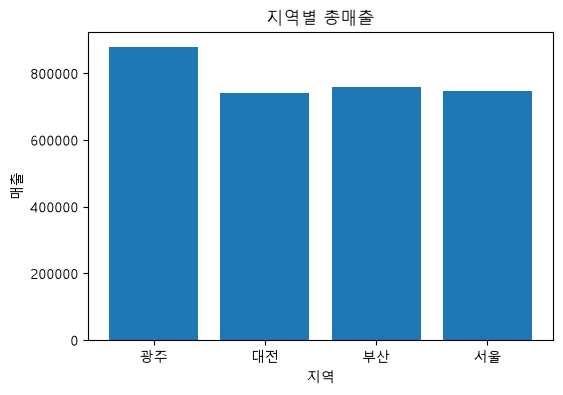

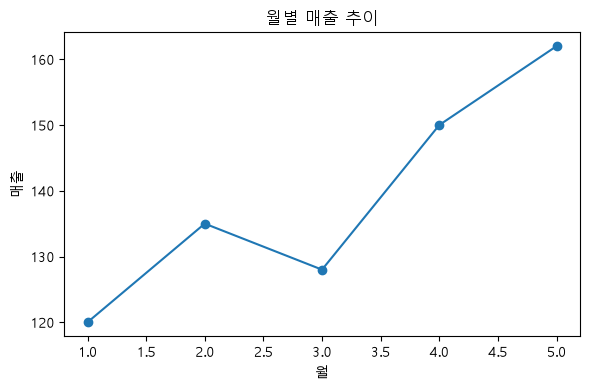

TODO 1 통과!


In [3]:
지역별매출 = df.groupby("지역")["매출"].sum()
월별매출 = [120, 135, 128, 150, 162]   # 1~5월 (가상)

# 1. ax1 에 막대그래프를 그려 주세요.
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.bar(지역별매출.index, 지역별매출.values)
ax1.set_title(L("지역별 총매출", "Sales by Region"))
ax1.set_xlabel(L("지역", "Region"))
ax1.set_ylabel(L("매출", "Sales"))

# 2. ax2 에 꺾은선그래프를 그려 주세요.
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(range(1, 6), 월별매출, marker="o")
ax2.set_title(L("월별 매출 추이", "Monthly Sales Trend"))
ax2.set_xlabel(L("월", "Month"))
ax2.set_ylabel(L("매출", "Sales"))

plt.tight_layout()
plt.show()

from matplotlib.figure import Figure
assert isinstance(fig1, Figure) and isinstance(fig2, Figure), "Figure 가 만들어지지 않았습니다."
assert len(ax1.patches) == len(지역별매출), "막대 개수가 지역 수와 다릅니다."
assert len(ax2.lines) >= 1, "꺾은선이 그려지지 않았습니다."
print("TODO 1 통과!")

### TODO 2: 서브플롯에 히스토그램과 산점도 배치하기

**요구사항**
- 2행 2열 서브플롯을 만들고, 준비된 `axes` 에 막대, 히스토그램, 산점도를 그립니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다.
- `axes[행, 열]` 로 각 축에 접근합니다. 축 객체는 `set_title` 로 제목을 붙입니다.

**힌트**
- 히스토그램 `axes[1, 0].hist(df["수량"], bins=5, edgecolor="black")`.
- 산점도 `axes[1, 1].scatter(df["단가"], df["수량"])`.
- 겹침 방지는 `plt.tight_layout()`.

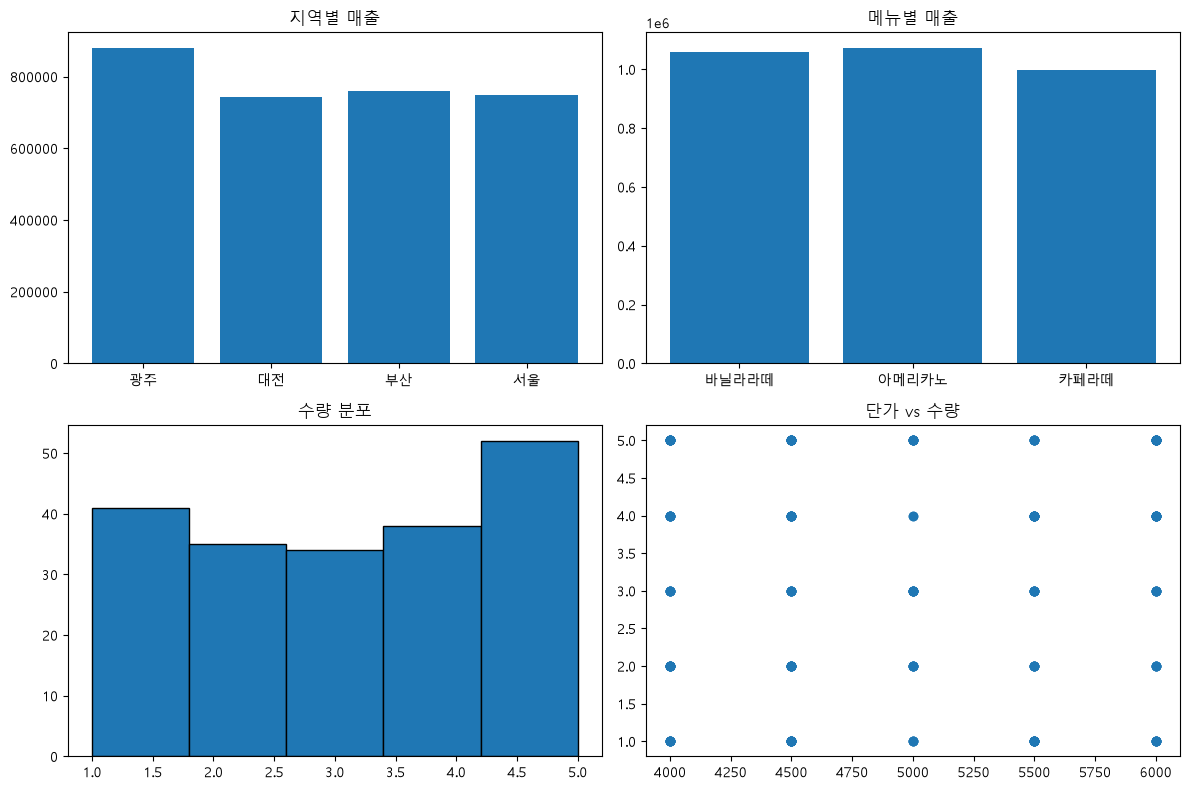

TODO 2 통과!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
지역별매출 = df.groupby("지역")["매출"].sum()
메뉴별매출 = df.groupby("메뉴")["매출"].sum()

# 1. axes[0, 0] 에 지역별 매출 막대그래프를 그려 주세요.
axes[0, 0].bar(지역별매출.index, 지역별매출.values)
axes[0, 0].set_title(L("지역별 매출", "Sales by Region"))

# 2. axes[0, 1] 에 메뉴별 매출 막대그래프를 그려 주세요.
axes[0, 1].bar(메뉴별매출.index, 메뉴별매출.values)
axes[0, 1].set_title(L("메뉴별 매출", "Sales by Menu"))

# 3. axes[1, 0] 에 수량 히스토그램을 그려 주세요. (bins=5, edgecolor="black")
axes[1, 0].hist(df["수량"], bins=5, edgecolor="black")
axes[1, 0].set_title(L("수량 분포", "Quantity Distribution"))

# 4. axes[1, 1] 에 단가 vs 수량 산점도를 그려 주세요.
axes[1, 1].scatter(df["단가"], df["수량"])
axes[1, 1].set_title(L("단가 vs 수량", "Price vs Quantity"))

plt.tight_layout()
plt.show()

assert axes.shape == (2, 2), "2행 2열 서브플롯이 아닙니다."
assert len(axes[0, 0].patches) == len(지역별매출), "지역별 막대 개수가 올바르지 않습니다."
assert len(axes[0, 1].patches) == len(메뉴별매출), "메뉴별 막대 개수가 올바르지 않습니다."
assert len(axes[1, 0].patches) == 5, "히스토그램 bins 가 5개가 아닙니다."
assert len(axes[1, 1].collections) >= 1, "산점도가 그려지지 않았습니다."
print("TODO 2 통과!")

## Step 3: Seaborn 통계 시각화

### Concept Check: Seaborn 통계 시각화

**Seaborn** 은 Matplotlib 기반의 통계 시각화 라이브러리입니다. 범주별 집계,분포를 짧은 코드로 그립니다. 한글 폰트 설정은 Matplotlib 과 동일하게 필요합니다.

| 함수 | 그리는 것 |
| --- | --- |
| `sns.barplot(data=df, x="지역", y="매출")` | 범주별 **평균** 비교 (막대 + 신뢰구간) |
| `sns.boxplot(data=df, x="메뉴", y="매출")` | 분포와 **이상치** (사분위수, 중앙값) |
| `sns.heatmap(df.corr(numeric_only=True), annot=True)` | 상관관계 등 행렬 시각화 |

`plt.bar` 는 입력한 값을 그립니다. `sns.barplot` 은 **그룹별 평균을 자동 계산**해 그립니다. `groupby` 를 따로 하지 않아도 됩니다.

**상관관계**: `df.corr(numeric_only=True)` 는 숫자 컬럼끼리의 상관계수(-1 ~ 1)를 표로 만듭니다. `annot=True` 를 주면 칸마다 숫자를 찍어 줍니다.

축을 지정할 때는 `ax=` 인자를 넘깁니다: `sns.barplot(data=df, x="지역", y="매출", ax=ax1)`.

### TODO 3: Seaborn 으로 그리기

**요구사항**
- `barplot` 으로 지역별 평균 매출, `boxplot` 으로 메뉴별 매출 분포, `heatmap` 으로 상관관계를 그립니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다.
- 준비된 `ax1`, `ax2`, `ax3` 에 각각 그립니다. (`ax=` 인자 사용)

**힌트**
- `sns.barplot(data=df, x="지역", y="매출", ax=ax1)`.
- `sns.boxplot(data=df, x="메뉴", y="매출", ax=ax2)`.
- `sns.heatmap(df.corr(numeric_only=True), annot=True, ax=ax3)`.

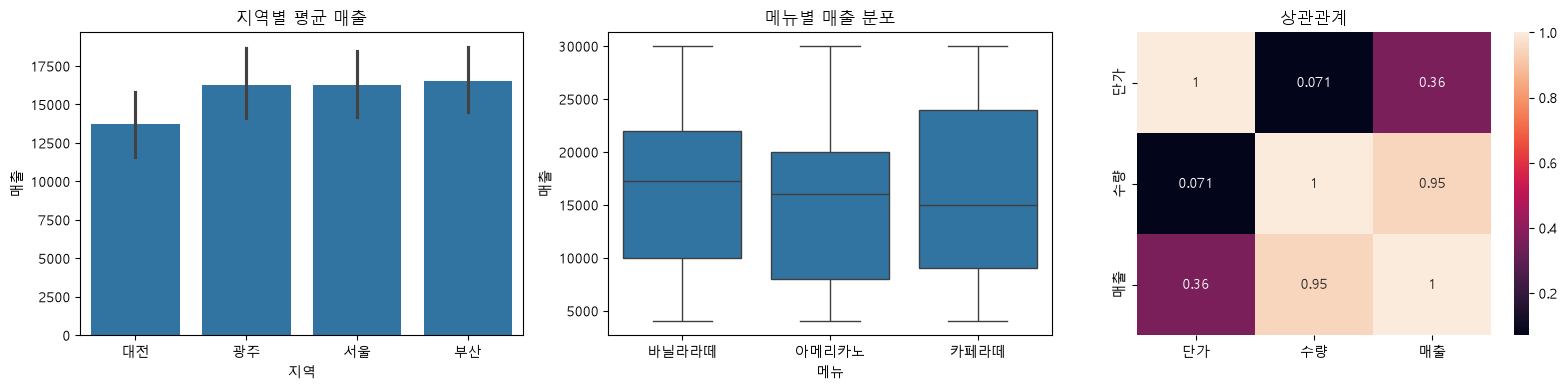

TODO 3 통과!


In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

# 1. ax1 에 지역별 평균 매출 barplot 을 그려 주세요.
sns.barplot(data=df, x="지역", y="매출", ax=ax1)
ax1.set_title(L("지역별 평균 매출", "Mean Sales by Region"))

# 2. ax2 에 메뉴별 매출 boxplot 을 그려 주세요.
sns.boxplot(data=df, x="메뉴", y="매출", ax=ax2)
ax2.set_title(L("메뉴별 매출 분포", "Sales Distribution by Menu"))

# 3. ax3 에 숫자 컬럼 상관관계 heatmap 을 그려 주세요. (annot=True)
상관표 = df.corr(numeric_only=True)
sns.heatmap(상관표, annot=True, ax=ax3)
ax3.set_title(L("상관관계", "Correlation"))

plt.tight_layout()
plt.show()

assert 상관표.shape == (3, 3), "숫자 컬럼 3개(단가,수량,매출)의 상관표가 아닙니다."
assert len(ax1.patches) == df["지역"].nunique(), "barplot 막대 개수가 지역 수와 다릅니다."
assert len(ax2.lines) > 0, "boxplot 이 그려지지 않았습니다."
assert len(ax3.collections) >= 1, "heatmap 이 그려지지 않았습니다."
print("TODO 3 통과!")

## Step 4: 데이터 전처리

### Concept Check: 분석 전에 데이터를 다듬는다

분석이나 모델링에 앞서 결측치와 이상치를 처리하고 값을 변환합니다. 원본은 보존하고 사본으로 작업합니다.

| 작업 | 문제 상황 | 대표 처리 |
| --- | --- | --- |
| 결측치 | 단가가 비어 있음(NaN) | 평균,중앙값,최빈값으로 채움 |
| 이상치 | 수량 99 (비정상 값) | 상한선으로 보정,제거 |
| 정규화 | 단가(4000대)와 수량(1~5) 범위 차이 큼 | 0~1 스케일로 변환 |
| 인코딩 | 메뉴가 글자라 계산 불가 | 숫자 코드로 변환 |

**찾기**: `df.isnull().sum()` 으로 컬럼별 결측 개수를, `df.describe()` 의 `min`,`max` 로 이상치 단서를 확인합니다. 박스플롯,히스토그램으로도 보입니다. 처리 전에 **왜 생겼는지**를 먼저 파악합니다.

**결측치 채우기**
- `fillna(값)` - 특정 값으로 채움. 평균 `df["단가"].mean()`, 중앙값 `median()`, 최빈값 `mode()[0]`
- 평균은 이상치의 영향을 받으므로, 분포가 치우치면 **중앙값**을 사용합니다.
- 범주형(글자)은 **최빈값**(`mode()`)으로 채웁니다. `mode()` 는 Series 를 반환하므로 `[0]` 으로 첫 값을 씁니다.
- `dropna()` 로 결측 행 전체를 버릴 수도 있으나 데이터 손실에 주의합니다.
- `notnull()` 은 `isnull()` 의 반대로, 값이 있는 행만 고를 때 `.loc` 의 조건으로 씁니다.

**이상치 - IQR(사분위 범위)**: `quantile()` 은 데이터를 크기순으로 나눈 기준값입니다. `Q1`(하위 25%), `Q3`(상위 75%), `IQR = Q3 - Q1` 을 구해 보통 `Q3 + 1.5 × IQR` 을 넘으면 이상치로 봅니다. `clip(upper=상한)` 으로 상한까지 잘라 냅니다. 수량처럼 정수여야 하는 값이면 상한도 정수로 내려 씁니다.

**정규화 - min-max**: `(값 - 최솟값) / (최댓값 - 최솟값)` 을 적용하면 모든 값이 0~1 범위로 들어옵니다.

**인코딩**: `map({"아메리카노": 0, ...})` 로 직접 매기거나 `astype("category").cat.codes` 로 자동 부여합니다. 대부분의 분석,모델은 숫자 입력만 받기 때문입니다.

아래 셀에서 전처리 실습을 위해 결측치 1개와 이상치 1개를 일부러 심어 둔 사본 `df2` 를 만듭니다.

In [6]:
# 전처리 실습용 사본: 결측치,이상치를 일부러 주입
df2 = df.copy()
df2.loc[5, "단가"] = np.nan    # 6번째 행 단가를 결측치로
df2.loc[10, "수량"] = 99       # 11번째 행 수량을 이상치로
df2["매출"] = df2["단가"] * df2["수량"]

print(df2.isnull().sum())      # 컬럼별 결측 개수
print("수량 최댓값:", int(df2["수량"].max()))

# quantile: 상위 10% 매출 경계값과 그 이상 주문
상위10경계 = df["매출"].quantile(0.9)
print("상위 10% 매출 경계:", 상위10경계)
print("상위 10% 주문 수:", len(df.loc[df["매출"] >= 상위10경계]))

지역    0
메뉴    0
단가    1
수량    0
매출    1
dtype: int64
수량 최댓값: 99
상위 10% 매출 경계: 27500.0
상위 10% 주문 수: 21


### TODO 4: 결측치 채우기 & 이상치 보정

**요구사항**
1. 단가 결측치를 평균 단가로 채웁니다. (`mean()` 은 NaN 을 자동 제외)
2. IQR 로 구한 상한을 넘는 수량을 `clip` 으로 상한값까지 자릅니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다. `None` 자리만 채웁니다.
- `fillna`, `clip` 결과는 다시 컬럼에 **재할당**해야 반영됩니다.
- 이 셀은 실행할 때마다 `df2` 를 새로 만듭니다. 빈칸을 다 채우기 전에 실행해도 다음 실행에서 다시 만들어집니다.

**힌트**
- 결측치 개수 `df2["단가"].isnull().sum()`, 채우기 `df2["단가"].fillna(평균단가)`.
- 상한 `int(Q3 + 1.5 * IQR)`, 자르기 `df2["수량"].clip(upper=상한)`.

In [7]:
# 이 셀은 다시 실행해도 되도록, 실습용 사본 df2 를 매번 새로 만듭니다.
df2 = df.copy()
df2.loc[5, "단가"] = np.nan    # 결측치 1개
df2.loc[10, "수량"] = 99       # 이상치 1개
df2["매출"] = df2["단가"] * df2["수량"]

# 1. 단가의 결측치 개수를 결측개수 에 할당해 주세요.
결측개수 = df2["단가"].isnull().sum()
assert 결측개수 == 1, "결측 개수가 올바르지 않습니다."

# 2. 평균 단가(NaN 자동 제외)를 평균단가 에 할당해 주세요.
평균단가 = df2["단가"].mean()

# 3. 단가 결측치를 평균단가 로 채우고 다시 df2["단가"] 에 할당해 주세요.
df2["단가"] = df2["단가"].fillna(평균단가)
assert df2["단가"].isnull().sum() == 0, "결측치가 남아 있습니다."

# 이상치 처리 (IQR) - Q1, Q3, IQR 은 제공됩니다.
Q1 = df2["수량"].quantile(0.25)
Q3 = df2["수량"].quantile(0.75)
IQR = Q3 - Q1

# 4. 이상치 상한을 정수로 구해 상한 에 할당해 주세요.
상한 = int(Q3 + 1.5 * IQR)

# 5. 상한을 넘는 수량을 상한으로 잘라 다시 df2["수량"] 에 할당해 주세요.
df2["수량"] = df2["수량"].clip(upper=상한)
df2["매출"] = df2["단가"] * df2["수량"]   # 매출 재계산
assert df2["수량"].max() <= 상한 and df2["수량"].max() < 99, "이상치가 보정되지 않았습니다."

print("TODO 4 통과!")

TODO 4 통과!


### TODO 5: 정규화 & 인코딩

**요구사항**
1. 매출을 min-max 정규화해 `매출정규화` 컬럼을 만듭니다. (모든 값이 0~1)
2. 메뉴(글자)를 숫자 코드로 인코딩해 `메뉴코드` 컬럼을 만듭니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다. `None` 자리만 채웁니다.

**힌트**
- 정규화 공식: `(값 - 최솟값) / (최댓값 - 최솟값)`.
- 인코딩: `df2["메뉴"].map({"아메리카노": 0, "카페라떼": 1, "바닐라라떼": 2})`.

In [8]:
최소매출 = df2["매출"].min()
최대매출 = df2["매출"].max()

# 1. 매출을 min-max 정규화해 "매출정규화" 컬럼을 만들어 주세요.
df2["매출정규화"] = (df2["매출"] - 최소매출) / (최대매출 - 최소매출)
assert abs(df2["매출정규화"].min() - 0.0) < 1e-9 and abs(df2["매출정규화"].max() - 1.0) < 1e-9, "정규화 결과가 0~1 범위가 아닙니다."

# 2. 메뉴(글자)를 숫자 코드로 인코딩해 "메뉴코드" 컬럼을 만들어 주세요.
메뉴맵 = {"아메리카노": 0, "카페라떼": 1, "바닐라라떼": 2}
df2["메뉴코드"] =df2["메뉴"].map(메뉴맵)
assert df2["메뉴코드"].nunique() == 3 and df2["메뉴코드"].min() == 0, "인코딩 결과가 올바르지 않습니다."
assert df2["메뉴코드"].isnull().sum() == 0, "매핑되지 않은 메뉴가 있습니다."

print("TODO 5 통과!")
df2[["메뉴", "메뉴코드", "매출", "매출정규화"]].head()

TODO 5 통과!


,메뉴,메뉴코드,매출,매출정규화
0,바닐라라떼,2,20000.0,0.438356
1,바닐라라떼,2,18000.0,0.383562
2,아메리카노,0,15000.0,0.301370
3,아메리카노,0,5500.0,0.041096
4,카페라떼,1,16000.0,0.328767


## Step 5: 변환 도구 - `drop`, `apply`, `cut`/`qcut`

### Concept Check: 컬럼을 지우고, 바꾸고, 구간으로 나누기

**`drop`** - 필요 없는 컬럼이나 행을 제거합니다. `axis=1` 은 열 삭제, `axis=0` 은 행 삭제. 여러 개는 리스트로 묶어 전달합니다. **원본은 유지되므로 결과를 다시 대입해야 반영됩니다.**

```python
df = df.drop(["메뉴"], axis=1)
```

**`apply`** - 컬럼의 모든 값에 함수를 적용합니다. `def` 로 만든 함수를 값마다 실행해 새 값을 만듭니다. `lambda`로도 작성할 수 있습니다.

```python
def grade(x):
    if x >= 5000:
        return "고가"
    else:
        return "저가"

df["가격대"] = df["단가"].apply(grade)
# lambda 로도 동일: df["단가"].apply(lambda x: "고가" if x >= 5000 else "저가")
```

**`cut` / `qcut`** - 연속형 데이터를 구간으로 나눠 범주로 바꿉니다.

| 함수 | 나누는 기준 |
| --- | --- |
| `pd.qcut(col, n)` | **개수가 같도록** n개 구간 (분위수 기준) |
| `pd.cut(col, n)` | **폭이 같도록** n개 구간 (등간격) |

결과는 구간(Interval) 범주형이며 `value_counts()` 로 분포를 확인합니다.

**`category` 타입** - 정해진 범주 값을 갖는 자료형입니다. 메모리를 아끼고 범주 순서를 지정할 수 있습니다. **없는 값을 채우려면 먼저 범주에 추가해야 합니다**: `.cat.add_categories("기타")` 로 새 범주를 넣은 뒤 `fillna("기타")` 를 씁니다. 타이타닉 `deck` 컬럼에도 이 방법을 적용합니다.

### TODO 6: `drop`, `apply`, 구간화

**요구사항**
1. 사본 `df4` 에서 `매출정규화` 컬럼을 삭제합니다.
2. `apply` 로 단가 5000 이상은 `"고가"`, 미만은 `"저가"` 인 `가격대` 컬럼을 만듭니다.
3. `qcut` 으로 매출을 5구간(동일 빈도), `cut` 으로 단가를 3구간(동일 폭)으로 나눕니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다. `None` 자리만 채웁니다.
- `drop` 은 결과를 다시 대입해야 반영됩니다.

**힌트**
- 열 삭제 `df4.drop(["매출정규화"], axis=1)`.
- `apply` 는 `df4["단가"].apply(grade)` 처럼 함수 이름만 넘깁니다(괄호 없이).
- 동일 빈도 `pd.qcut(df4["매출"], 5)`, 동일 폭 `pd.cut(df4["단가"], 3)`.

In [9]:
df4 = df2.copy()

# 1. 매출정규화 컬럼을 삭제해 다시 df4 에 할당해 주세요.
df4 = df4.drop(["매출정규화"], axis=1)
assert "매출정규화" not in df4.columns, "컬럼이 삭제되지 않았습니다."

# 2. 단가 5000 이상이면 "고가", 아니면 "저가" 를 돌려주는 함수를 완성해 주세요.
def grade(x):
    if x >= 5000:
        return "고가"
    else:
        return "저가"

# 3. apply 로 grade 를 적용해 "가격대" 컬럼을 만들어 주세요.
df4["가격대"] = df4["단가"].apply(grade)
assert set(df4["가격대"].unique()) <= {"고가", "저가"}, "가격대 값이 올바르지 않습니다."
assert (df4.loc[df4["단가"] >= 5000, "가격대"] == "고가").all(), "고가 분류가 올바르지 않습니다."

# 4. 매출을 동일 빈도 5구간으로 나눠 "매출구간" 컬럼을 만들어 주세요.
df4["매출구간"] = pd.qcut(df4["매출"], 5)
assert df4["매출구간"].nunique() == 5, "qcut 구간이 5개가 아닙니다."

# 5. 단가를 동일 폭 3구간으로 나눠 "단가구간" 컬럼을 만들어 주세요.
df4["단가구간"] = pd.cut(df4["단가"], 3)
assert df4["단가구간"].nunique() == 3, "cut 구간이 3개가 아닙니다."

print("TODO 6 통과!")
print(df4["매출구간"].value_counts())

TODO 6 통과!
매출구간
(12000.0, 18000.0]    44
(7600.0, 12000.0]     41
(3999.999, 7600.0]    40
(22800.0, 40500.0]    40
(18000.0, 22800.0]    35
Name: count, dtype: int64


## Step 6: EDA - 타이타닉 데이터 구조 파악

### Concept Check: 탐색적 데이터 분석 (Exploratory Data Analysis)

**EDA** 는 데이터를 그래프와 통계로 확인하며 분포와 문제를 파악하는 과정입니다.

**목적**
- 데이터의 분포와 값을 검토해 데이터가 표현하는 현상을 이해합니다.
- 데이터의 문제(결측, 이상치)를 발견합니다.
- 문제 정의 단계에서 놓친 패턴을 찾아 기존 가설을 수정하거나 새 가설을 세웁니다.

**표준 흐름**

1. 분석의 목적 설계 및 데이터 확보
2. 데이터 탐색 (`shape`/`info`/`describe`, Null, 이상치)
3. 데이터 값 관찰 및 변환 (`groupby` 집계, 전처리)

**타이타닉 승객 데이터**로 EDA 전 과정을 수행합니다. 조회, 필터, 집계 방법은 라이브 2 와 같습니다.

**STEP 1: 문제 정의 및 목표 설정**

- **목표**: 타이타닉 호 승객 데이터를 기반으로 생존에 영향을 미치는 요인 분석
- **주요 과제**: 기본 EDA, 데이터 전처리, 생존 요인 분석

**데이터 컬럼 설명**

| 컬럼 | 의미 | | 컬럼 | 의미 |
| --- | --- | --- | --- | --- |
| `survived` | 생존여부 (1 생존, 0 사망) | | `class` | `pclass` 와 동일 |
| `pclass` | 좌석 등급 (1,2,3등급) | | `who` | man / woman / child |
| `sex` | 성별 | | `adult_male` | 성인 남자 여부 |
| `age` | 나이 | | `deck` | 데크 번호 |
| `sibsp` | 형제 + 배우자 수 | | `embark_town` | 탑승 항구 이름 |
| `parch` | 부모 + 자녀 수 | | `alive` | 생존여부 (yes, no) |
| `fare` | 좌석 요금 | | `alone` | 혼자 탑승 여부 |
| `embarked` | 탑승 항구 (S, C, Q) | | | |

In [10]:
# STEP 2-3: 데이터셋 불러오기 (Seaborn 내장 타이타닉)
from pathlib import Path

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
TITANIC_LOCAL_CANDIDATES = [Path("data/titanic.csv"), Path("../data/titanic.csv")]

try:
    titanic = sns.load_dataset("titanic")
    출처 = "seaborn"
except Exception as seaborn_error:
    print("seaborn 로드 실패, CSV 주소에서 직접 읽기:", seaborn_error)
    try:
        titanic = pd.read_csv(TITANIC_URL)
        출처 = "CSV URL"
    except Exception as url_error:
        local_path = next((path for path in TITANIC_LOCAL_CANDIDATES if path.exists()), None)
        if local_path is None:
            raise FileNotFoundError("data/titanic.csv를 찾을 수 없습니다. 배포 폴더 구조를 확인하세요.") from url_error
        print("CSV 주소 로드 실패, 로컬 데이터 사용:", url_error)
        titanic = pd.read_csv(local_path)
        출처 = f"로컬 CSV ({local_path})"
    for col in ["class", "deck"]:
        titanic[col] = titanic[col].astype("category")   # 범주형으로 복원

print("데이터 출처:", 출처, "| 크기:", titanic.shape)
titanic.head()

데이터 출처: seaborn | 크기: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### TODO 7: 기본 데이터 조회 (STEP 4)

**요구사항**
- 처음 받은 표의 크기, 결측, 분포를 확인합니다. EDA 체크리스트의 첫 단계입니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다. `None` 자리만 채웁니다.

**힌트**
- 상위 5행 `titanic.head()`, 하위 5행 `titanic.tail()`, 크기 `titanic.shape`.
- 컬럼별 결측치 `titanic.isnull().sum()`, 생존자 분포 `titanic["survived"].value_counts()`.

In [11]:
# 1. 상위 5개 행을 상위5행 에 할당해 주세요.
상위5행 = titanic.head()
assert len(상위5행) == 5, "head() 결과가 올바르지 않습니다."

# 2. 하위 5개 행을 하위5행 에 할당해 주세요.
하위5행 = titanic.tail()
assert len(하위5행) == 5, "tail() 결과가 올바르지 않습니다."

# 3. (행, 열) 크기를 크기 에 할당해 주세요.
크기 = titanic.shape
assert 크기 == (891, 15), "shape 가 올바르지 않습니다."

# 4. 컬럼별 결측치 개수를 결측치 에 할당해 주세요.
결측치 = titanic.isnull().sum()
assert 결측치["age"] == 177 and 결측치["deck"] == 688 and 결측치["embarked"] == 2, "결측치 집계가 올바르지 않습니다."

# 5. 생존자와 사망자의 분포를 생존분포 에 할당해 주세요.
생존분포 = titanic["survived"].value_counts()
assert 생존분포[0] == 549 and 생존분포[1] == 342, "생존 분포가 올바르지 않습니다."

print("TODO 7 통과!")
titanic.info()

TODO 7 통과!
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## Step 7: EDA - `groupby` 로 생존 요인 탐색 (STEP 5)

### Concept Check: 분석 질문을 집계로 바꾸기

분석 질문에 맞는 집계 방법을 선택합니다. `survived` 는 0/1 이므로 `sum` 은 생존자 수, `mean` 은 **생존율**이 됩니다. 따라서 `agg(["sum", "mean"])` 한 줄로 두 값을 함께 볼 수 있습니다.

```python
titanic.groupby("sex")["survived"].agg(["sum", "mean"])
# sum  = 생존자 수, mean = 생존율
```

| 분석 질문 | 집계 코드 |
| --- | --- |
| 항구별 생존율은? | `groupby("embarked")["survived"].mean()` |
| 성별 생존율은? | `groupby("sex")["survived"].agg(["sum", "mean"])` |
| 성별 × 등급별 생존율은? | `groupby(["sex", "pclass"])["survived"].agg(["sum", "mean"])` |
| 부자는 살았을까? | `fare` 상위 10% 경계를 `quantile(0.9)` 로 구해 필터 |
| 생존자와 사망자의 평균 나이 차이는? | `groupby("survived")["age"].mean()` |

두 컬럼으로 묶으면 계층 인덱스(MultiIndex)가 생깁니다. `reset_index()` 로 일반 컬럼으로 되돌린 뒤 `sort_values` 로 정렬하면 순위표가 됩니다.

In [12]:
# 항구별 생존자 합계와 생존율 (sum = 생존자 수, mean = 생존율)
print(titanic.groupby("embarked")["survived"].agg(["sum", "mean"]))

# 성별, 등급별 생존율
print(titanic.groupby(["sex", "pclass"])["survived"].agg(["sum", "mean"]))

# 혼자 탑승 여부 × 성별 생존율
print(titanic.groupby(["alone", "sex"])["survived"].agg(["sum", "mean"]))

# 생존자와 사망자의 평균 나이
print(titanic.groupby("survived")["age"].mean())

# deck 정보가 없는 경우와 있는 경우의 생존율 비교
print("deck 결측 생존율:", round(titanic.loc[titanic["deck"].isnull(), "survived"].mean(), 4))
print("deck 존재 생존율:", round(titanic.loc[titanic["deck"].notnull(), "survived"].mean(), 4))

          sum      mean
embarked               
C          93  0.553571
Q          30  0.389610
S         217  0.336957
               sum      mean
sex    pclass               
female 1        91  0.968085
       2        70  0.921053
       3        72  0.500000
male   1        45  0.368852
       2        17  0.157407
       3        47  0.135447
              sum      mean
alone sex                  
False female  134  0.712766
      male     45  0.271084
True  female   99  0.785714
      male     64  0.155718
survived
0    30.626179
1    28.343690
Name: age, dtype: float64
deck 결측 생존율: 0.2994
deck 존재 생존율: 0.67


### TODO 8: 그룹별 생존율 구하기

**요구사항**
- 성별, 혼자 탑승 여부, 등급, 그리고 who × 등급별 생존자 수와 생존율을 구합니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다. `None` 자리만 채웁니다.

**힌트**
- 합계와 평균 동시에: `titanic.groupby("sex")["survived"].agg(["sum", "mean"])`.
- 다중 그룹: `titanic.groupby(["who", "pclass"])["survived"].agg(["sum", "mean"])`.
- 순위표 만들기: `.reset_index()` 뒤 `.sort_values(by="mean", ascending=False)`.

In [13]:
# 1. 성별 생존자 합계 & 생존율을 성별생존 에 할당해 주세요.
성별생존 = titanic.groupby("sex")["survived"].agg(["sum", "mean"])
assert 성별생존.loc["female", "sum"] == 233 and round(성별생존.loc["female", "mean"], 3) == 0.742, "성별 생존 집계가 올바르지 않습니다."

# 2. 혼자 탑승 여부(alone)별 생존자 합계 & 생존율을 혼자생존 에 할당해 주세요.
혼자생존 = titanic.groupby("alone")["survived"].agg(["sum", "mean"])
assert list(혼자생존.columns) == ["sum", "mean"] and len(혼자생존) == 2, "alone 생존 집계가 올바르지 않습니다."

# 3. 등급(pclass)별 생존율을 등급생존율 에 할당해 주세요.
등급생존율 = titanic.groupby("pclass")["survived"].mean()
assert round(등급생존율[1], 3) == 0.63 and round(등급생존율[3], 3) == 0.242, "등급별 생존율이 올바르지 않습니다."

# 4. who × 등급(pclass)별 생존자 합계 & 생존율을 who등급 에 할당해 주세요.
who등급 = titanic.groupby(["who", "pclass"])["survived"].agg(["sum", "mean"])
assert who등급.index.nlevels == 2 and len(who등급) == 9, "who × pclass 집계가 올바르지 않습니다."

# 5. who등급 을 생존율(mean) 내림차순 순위표로 만들어 순위표 에 할당해 주세요.
순위표 = who등급.reset_index().sort_values(by="mean", ascending=False)
assert list(순위표.columns) == ["who", "pclass", "sum", "mean"], "순위표 컬럼이 올바르지 않습니다."
assert 순위표["mean"].is_monotonic_decreasing, "생존율 내림차순 정렬이 아닙니다."

print("TODO 8 통과!")
순위표

TODO 8 통과!


,who,pclass,sum,mean
1,child,2,19,1.000000
6,woman,1,89,0.978022
7,woman,2,60,0.909091
0,child,1,5,0.833333
8,woman,3,56,0.491228
2,child,3,25,0.431034
3,man,1,42,0.352941
5,man,3,38,0.119122
4,man,2,8,0.080808


### TODO 9: `pivot_table` 과 `quantile` 로 답하기

**요구사항**
1. `pivot_table` 로 성별(세로) × 등급(가로) 생존자 합계,생존율을 교차 집계합니다.
2. child 의 나이 범위를 확인합니다.
3. "부자는 살았을까?" - 요금 상위 10% 승객의 생존율을 구합니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다. `None` 자리만 채웁니다.

**힌트**
- 교차 집계: `titanic.pivot_table(index="sex", columns="pclass", values="survived", aggfunc=["sum", "mean"])`.
- 조건에 맞는 행의 특정 열: `titanic.loc[titanic["who"] == "child", "age"].agg(["min", "max"])`.
- 상위 10% 경계: `titanic["fare"].quantile(0.9)`. 그 이상 승객: `titanic.loc[titanic["fare"] >= rich, "survived"].agg(["count", "mean"])`.

In [14]:
# 1. 성별(세로) × 등급(가로) 생존자 합계,생존율을 피벗 에 할당해 주세요.
피벗 = titanic.pivot_table(index="sex", columns="pclass", values="survived", aggfunc=["sum", "mean"])
assert 피벗.shape == (2, 6), "pivot_table 모양이 올바르지 않습니다."

# 2. child 의 age 최솟값과 최댓값을 child나이 에 할당해 주세요.
child나이 = titanic.loc[titanic["who"] == "child", "age"].agg(["min", "max"])
assert child나이["min"] == 0.42 and child나이["max"] == 15.0, "child 나이 범위가 올바르지 않습니다."

# 3. 등급별,연령대별(who) 평균 요금을 평균요금 에 할당해 주세요.
평균요금 = titanic.groupby(["pclass", "who"])[["fare"]].mean()
assert 평균요금.index.nlevels == 2 and "fare" in 평균요금.columns, "평균 요금 집계가 올바르지 않습니다."

# 4. fare 기준 상위 10% 경계값을 rich 에 할당해 주세요.
rich = titanic["fare"].quantile(0.9)
assert round(rich, 2) == 77.96, "상위 10% 경계값이 올바르지 않습니다."

# 5. 요금이 rich 이상인 승객의 인원수와 생존율을 부자생존 에 할당해 주세요.
부자생존 = titanic.loc[titanic["fare"] >= rich, "survived"].agg(["count", "mean"])
assert 부자생존["count"] == 90 and round(부자생존["mean"], 3) == 0.767, "상위 10% 생존율이 올바르지 않습니다."

print("TODO 9 통과!")
print("상위 10% 요금 경계:", round(rich, 2), "| 인원:", int(부자생존["count"]), "| 생존율:", round(부자생존["mean"], 3))
피벗

TODO 9 통과!
상위 10% 요금 경계: 77.96 | 인원: 90 | 생존율: 0.767


sum              mean                    
pclass   1   2   3         1         2         3
sex                                             
female  91  70  72  0.968085  0.921053  0.500000
male    45  17  47  0.368852  0.157407  0.135447

## Step 8: 미니 프로젝트 - 타이타닉 전처리와 특성 공학 (STEP 6)

EDA 로 확인한 결측치를 채우고, 중복 컬럼을 지우고, 새 특성을 만들어 분석에 사용할 형태로 다듬습니다.

**결측치 처리 방침**

| 컬럼 | 결측 수 | 처리 방침 |
| --- | --- | --- |
| `embarked` | 2 | 최빈값(`mode`)으로 대체 |
| `age` | 177 | **성별 평균 나이**로 대체 (남자는 남자 평균, 여자는 여자 평균) |
| `deck` | 688 | `"No Data"` 범주를 추가해 대체 |

`age` 를 **성별 평균으로 나눠 채우는** 이유는 남녀의 평균 나이가 다르기 때문입니다.

**특성 공학(feature engineering)**: 기존 컬럼을 조합해 분석에 쓸모 있는 새 컬럼을 만드는 작업입니다. `family = sibsp + parch` 처럼 두 컬럼을 합치면 동승 가족 수를 값 하나로 분석할 수 있습니다.

### TODO 10: 결측치 대체

**요구사항**
1. `embarked` 를 최빈값으로 채웁니다.
2. `age` 를 **성별 평균 나이**로 채웁니다.
3. `deck` 은 `"No Data"` 범주를 추가한 뒤 채웁니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다. `None` 자리만 채웁니다.
- 원본은 보존하고 사본 `t` 로 작업합니다.

**힌트**
- 최빈값은 Series 라서 `[0]` 이 필요합니다: `t["embarked"].mode()[0]`.
- 성별 평균: `t.groupby("sex")["age"].mean()["male"]`. 대체는 `.loc` 으로 남/녀를 나눠 `fillna` 합니다.
- `deck` 은 `category` 타입이라 등록되지 않은 값을 채울 수 없습니다. `t["deck"].cat.add_categories("No Data")` 로 범주를 먼저 추가하세요.

In [15]:
t = titanic.copy()

# 1. embarked 의 최빈값을 최빈항구 에 할당하고, 결측치를 채워 주세요.
최빈항구 = t["embarked"].mode()[0]
t["embarked"] = t["embarked"].fillna(최빈항구)
assert 최빈항구 == "S" and t["embarked"].isnull().sum() == 0, "embarked 대체가 올바르지 않습니다."

# 2. 성별 평균 나이를 남자평균, 여자평균 에 할당해 주세요.
남자평균 = t.groupby("sex")["age"].mean()["male"]
여자평균 = t.groupby("sex")["age"].mean()["female"]
assert round(남자평균, 2) == 30.73 and round(여자평균, 2) == 27.92, "성별 평균 나이가 올바르지 않습니다."

# 3. age 결측치를 성별 평균으로 채워 주세요.
t.loc[t["sex"] == "male", "age"] = t.loc[t["sex"] == "male", "age"].fillna(남자평균)
t.loc[t["sex"] == "female", "age"] = t.loc[t["sex"] == "female", "age"].fillna(여자평균)
# TODO: 여기에 코드를 작성하세요
assert t["age"].isnull().sum() == 0, "age 결측치가 남아 있습니다."
assert round(t.groupby("sex")["age"].mean()["female"], 2) == 27.92, "여자 평균 나이가 바뀌었습니다."
assert round(t.groupby("sex")["age"].mean()["male"], 2) == 30.73, "남자 평균 나이가 바뀌었습니다."

# 4. deck 에 "No Data" 범주를 추가한 뒤 결측치를 채워 주세요.
t["deck"] = t["deck"].cat.add_categories("No Data")
t["deck"] = t["deck"].fillna("No Data")
assert t["deck"].isnull().sum() == 0, "deck 결측치가 남아 있습니다."
assert (t["deck"] == "No Data").sum() == 688, "No Data 개수가 올바르지 않습니다."

t_기준 = t.copy()   # TODO 11 을 여러 번 실행해도 되도록 결과를 보관

print("TODO 10 통과!")
print(t.isnull().sum())

TODO 10 통과!
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    2
alive          0
alone          0
dtype: int64


### TODO 11: 중복 컬럼 제거와 특성 공학

**요구사항**
1. 중복 컬럼(`class`, `embark_town`, `alive`)을 제거합니다.
2. `family = sibsp + parch` 컬럼을 만듭니다.
3. `apply` 로 남자는 1, 여자는 0 인 `gender` 컬럼을 만듭니다.
4. `qcut` 으로 요금을 5구간, `cut` 으로 나이를 10구간으로 나눕니다.
5. 성별 × 가족 수별 생존율 순위표를 만들어 TOP 5 와 하위 10 을 뽑습니다.

**제한조건**
- 정답 확인용 `assert` 줄은 수정하지 않습니다. `None` 자리만 채웁니다.
- `drop` 은 결과를 다시 대입해야 반영됩니다.

**힌트**
- 여러 컬럼 삭제: `t.drop(["class", "embark_town", "alive"], axis=1)`.
- 동일 분포 5구간 `pd.qcut(t["fare"], 5)`, 동일 폭 10구간 `pd.cut(t["age"], 10)`.
- 순위표: `groupby([...])["survived"].mean().reset_index().sort_values("survived", ascending=False)`.
- 상위는 `result.head()`, 하위는 `result.tail(10)`. 둘 다 `.reset_index(drop=True)` 로 번호를 다시 매깁니다.

In [16]:
t = t_기준.copy()   # TODO 10 결과에서 이어 시작 (이 셀을 다시 실행할 수 있습니다)

# 1. class, embark_town, alive 컬럼을 제거해 다시 t 에 할당해 주세요.
t = t.drop(["class", "embark_town", "alive"], axis=1)
assert t.shape[1] == 12, "컬럼 수가 12개가 아닙니다."
assert not {"class", "embark_town", "alive"} & set(t.columns), "중복 컬럼이 남아 있습니다."

# 2. sibsp + parch 를 더해 "family" 컬럼을 만들어 주세요.
t["family"] = t["sibsp"] + t["parch"]
assert t["family"].max() == 10 and (t["family"] == t["sibsp"] + t["parch"]).all(), "family 컬럼이 올바르지 않습니다."

# 3. 남자는 1, 여자는 0 을 돌려주는 함수를 완성하고 apply 로 "gender" 컬럼을 만들어 주세요.
def make_bin(x):
    if x == "male":
        return 1
    else:
        return 0

t["gender"] = t["sex"].apply(make_bin)
assert t["gender"].sum() == (t["sex"] == "male").sum(), "gender 인코딩이 올바르지 않습니다."
assert set(t["gender"].unique()) == {0, 1}, "gender 값이 0/1 이 아닙니다."

# 4. 요금을 동일 분포 5구간으로 나눠 "fare_bin" 컬럼을 만들어 주세요.
t["fare_bin"] = pd.qcut(t["fare"], 5)
assert t["fare_bin"].nunique() == 5, "fare_bin 구간이 5개가 아닙니다."

# 5. 나이를 동일 폭 10구간으로 나눠 "age_bin" 컬럼을 만들어 주세요.
t["age_bin"] = pd.cut(t["age"], 10)
assert t["age_bin"].nunique() == 10, "age_bin 구간이 10개가 아닙니다."

# 6. 성별 × 가족 수별 생존율 TOP 5 를 top5 에 할당해 주세요.
result = t.groupby(["sex", "family"])["survived"].mean().reset_index().sort_values("survived", ascending=False)
top5 = result.head().reset_index(drop=True)
assert len(top5) == 5 and top5["survived"].is_monotonic_decreasing, "TOP 5 순위표가 올바르지 않습니다."

# 7. 같은 순위표에서 생존율 하위 10 개를 bottom10 에 할당해 주세요.
bottom10 = result.tail(10).reset_index(drop=True)
assert len(bottom10) == 10 and bottom10["survived"].iloc[-1] == result["survived"].min(), "하위 10 순위표가 올바르지 않습니다."

print("TODO 11 통과! 미니 프로젝트 완성")
print(t["fare_bin"].value_counts())
top5

TODO 11 통과! 미니 프로젝트 완성
fare_bin
(7.854, 10.5]        184
(21.679, 39.688]     180
(-0.001, 7.854]      179
(39.688, 512.329]    176
(10.5, 21.679]       172
Name: count, dtype: int64


,sex,family,survived
0,female,3,0.842105
1,female,1,0.816092
2,female,0,0.785714
3,female,2,0.775510
4,male,3,0.500000


## 학생용 자가 체크리스트

- [ ] 데이터 특성에 맞는 차트(막대/꺾은선/산점도/히스토그램/박스플롯)를 고를 수 있다
- [ ] 한글 폰트를 설정해 라벨 깨짐을 막고 서브플롯에 여러 차트를 배치할 수 있다
- [ ] Seaborn 으로 `barplot`,`boxplot`,`heatmap` 을 그릴 수 있다
- [ ] 결측치를 평균,중앙값,최빈값으로 채우고 IQR 로 이상치를 보정할 수 있다
- [ ] min-max 정규화와 범주형 인코딩을 적용할 수 있다
- [ ] `drop`,`apply`,`cut`/`qcut` 으로 컬럼을 지우고 바꾸고 구간화할 수 있다
- [ ] 처음 받은 데이터에 EDA 표준 흐름(구조 파악 , 결측,이상치 , 집계)을 적용할 수 있다
- [ ] `groupby`,`pivot_table`,`quantile` 로 분석 질문에 답할 수 있다
- [ ] 특성 공학으로 새 컬럼을 만들어 분석에 사용할 형태로 다듬을 수 있다

---

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW,AI아카데미의 콘텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.